# **EP1 - Controle de Qualidade Automatizado**


Disciplina: MAC 0417/5768 - Visão e Processamento de Imagens

Ísis Ardisson Logullo - nUSP 7577410

### **Importação de Bibliotecas e Download da Imagem**

In [11]:
import gdown
import numpy as np
import matplotlib.pyplot as plt

file_id = '1pTILSYmc2UEXNMuOhXyhA91Z0DFxaeY9'
url = f'https://drive.google.com/uc?id={file_id}'
output_file = 'ep1_grayscale_8bit.png'
gdown.download(url, output_file, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1pTILSYmc2UEXNMuOhXyhA91Z0DFxaeY9
To: /content/ep1_grayscale_8bit.png
100%|██████████| 661k/661k [00:00<00:00, 8.14MB/s]


'ep1_grayscale_8bit.png'

### **Carregamento e Visualização**

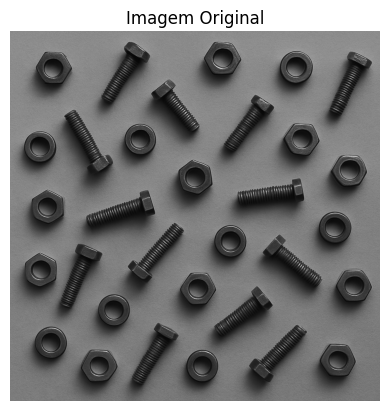

In [13]:
def load_image(file_path):
    img = plt.imread(file_path)
    if img.dtype != np.uint8:
        img = (img * 255).astype(np.uint8)
    return img

input_img = load_image(output_file)
plt.imshow(input_img, cmap='gray')
plt.title("Imagem Original")
plt.axis('off')
plt.show()

### **Histograma**

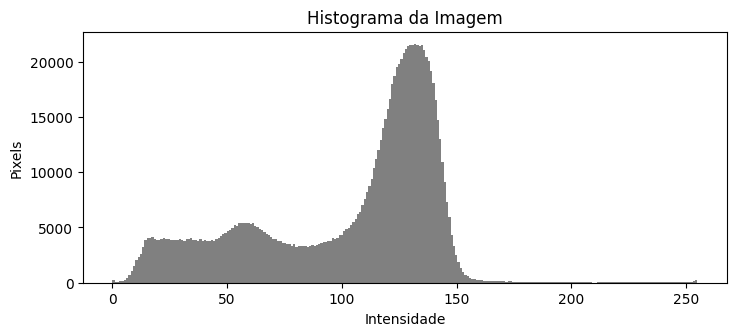

In [18]:
def histograma(img):
    plt.figure(figsize=(8, 4))
    plt.hist(img.ravel(), bins=256, range=(0, 255), color='gray')
    plt.title("Histograma da Imagem")
    plt.xlabel("Intensidade")
    plt.ylabel("Pixels")
    plt.tight_layout(pad=3.0)
    plt.show()

histograma(input_img)

### **Limiarização**

Aplicação de limiares:

1.   Limiares Baixos (50, 60): Os objetos podem aparecer "roídos" ou com buracos artificiais, pois partes cinza-escuras do objeto acabam sendo classificadas como fundo.

2.   Limiar Ideal (80): Os objetos estão bem definidos e separados do fundo, preservando o formato original.

3.   Limiares Altos (120, 140): Começa a aparecer muito ruído do fundo (pontos pretos onde deveria ser branco) e os objetos podem começar a "grudar" uns nos outros devido à sombra ou reflexos na esteira.


Escolher um limiar errado nesta etapa, a contagem de componentes conexos vai falhar:

* Se os objetos grudarem (T muito alto), ela contará menos objetos.

* Se os objetos quebrarem (T muito baixo), ela contará mais objetos.


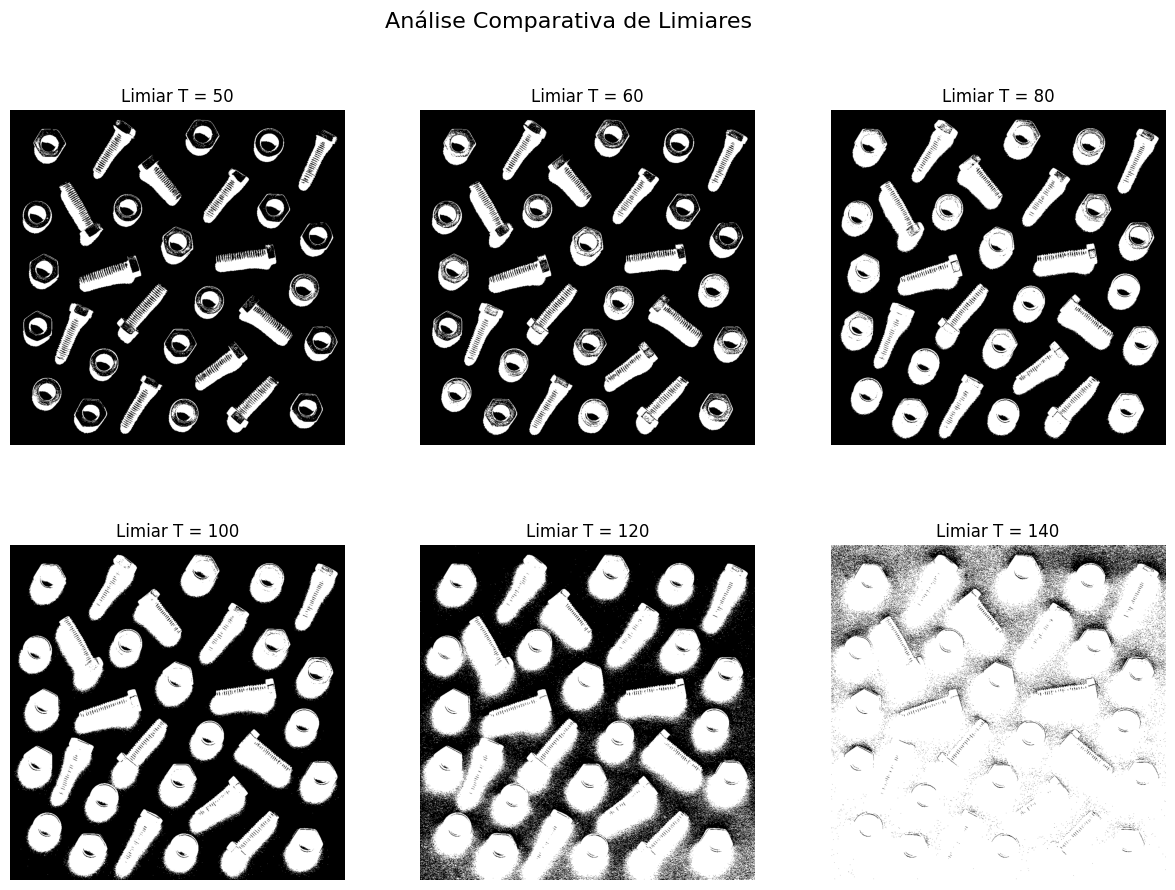

In [36]:
thresh_vals = [50, 60, 80, 100, 120, 140]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, t in enumerate(thresh_vals):
    img_bin = limiar(input_img, t)

    axes[i].imshow(img_bin, cmap='gray')
    axes[i].set_title(f"Limiar T = {t}")
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.3, wspace=0.2)
plt.suptitle("Análise Comparativa de Limiares", fontsize=16)
plt.show()

Gerando imagem Binária:

Com limiar ótimo T = 80

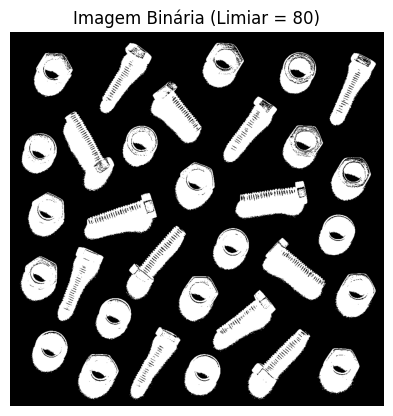

In [19]:
def limiar(img, t):
    # b(x,y) = 255 se f(x,y) <= t; caso contrário 0
    return np.where(img <= t, 255, 0).astype(np.uint8)

binary_img = limiar(input_img, 80)

plt.imshow(binary_img, cmap='gray')
plt.title("Imagem Binária (Limiar = 80)")
plt.axis('off')
plt.tight_layout(pad=3.0)
plt.show()

### **Filtragem**

Para remover ruídos internos (pequenas regiões escuras), aplicamos um filtro de máxima. Essa filtragem ajudará na contagem, deixando os objetos conexos mais evidentes.

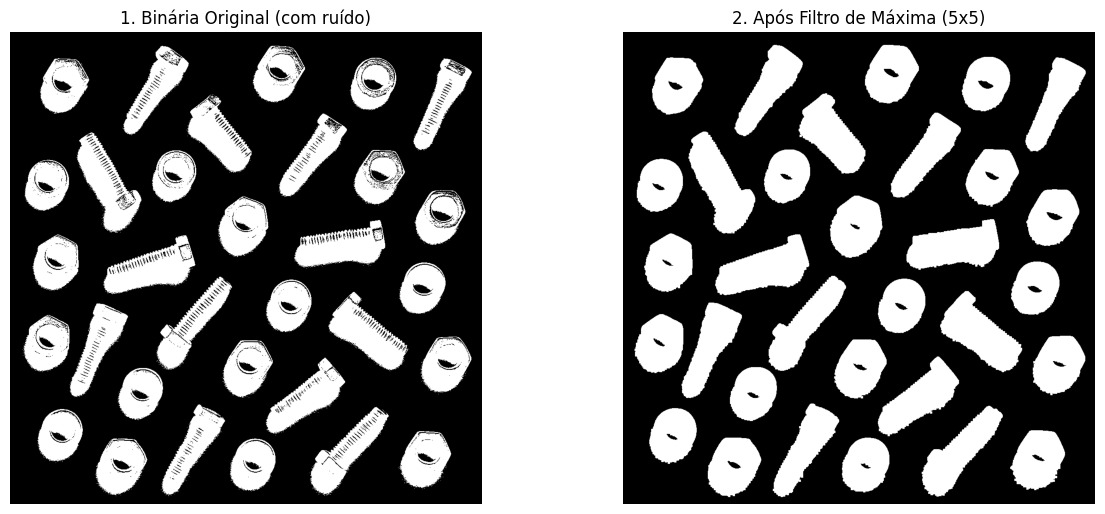

In [24]:
def filtro_maxima(img):
    # Padding de 2 pixels com zeros [cite: 475]
    padded = np.pad(img, 2, mode='constant', constant_values=0)
    out = np.zeros_like(img)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            # Kernel 5x5 [cite: 473]
            region = padded[i:i+5, j:j+5]
            out[i, j] = np.max(region)
    return out

filtered_img = filtro_maxima(binary_img)
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Imagem Binária Original (com ruídos internos)
ax[0].imshow(binary_img, cmap='gray')
ax[0].set_title("1. Binária Original (com ruído)")
ax[0].axis('off')

# Imagem após Filtro de Máxima (limpa)
ax[1].imshow(filtered_img, cmap='gray')
ax[1].set_title("2. Após Filtro de Máxima (5x5)")
ax[1].axis('off')

plt.subplots_adjust(wspace=0.3)
plt.show()


### **Estrutura Union-Find**

 Definimos as funções obrigatórias para rotulação de componentes conexos.

In [27]:
def makeset(n):
    return list(range(n)), [0] * n

def find(i, parent):
    if parent[i] == i:
        return i
    parent[i] = find(parent[i], parent)
    return parent[i]

def union(i, j, parent, rank):
    root_i = find(i, parent)
    root_j = find(j, parent)
    if root_i != root_j:
        if rank[root_i] < rank[root_j]:
            parent[root_i] = root_j
        elif rank[root_i] > rank[root_j]:
            parent[root_j] = root_i
        else:
            parent[root_j] = root_i
            rank[root_i] += 1

print("Estrutura Union-Find carregada com sucesso.")
print(f"Dimensões da imagem filtrada: {filtered_img.shape}")

Estrutura Union-Find carregada com sucesso.
Dimensões da imagem filtrada: (1024, 1024)


### Complemento  da Imagem



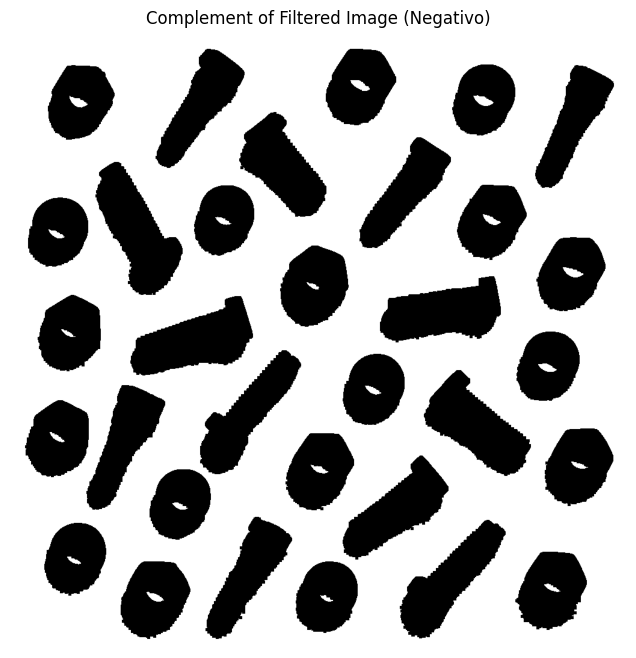

In [37]:
def complemento(img):
    # Inverte os valores: 255 vira 0, 0 vira 255
    return np.where(img == 255, 0, 255).astype(np.uint8)

complement_filtered_img = complemento(filtered_img)

plt.figure(figsize=(8, 8))
plt.imshow(complement_filtered_img, cmap="gray")
plt.title("Complement of Filtered Image (Negativo)")
plt.axis("off")
plt.show()

### **Contagem dos Componentes**

1.   Parafusos: São objetos simplesmente conexos. Se você olhar para o "negativo" da imagem, não existe um buraco de fundo (preto) dentro de um parafuso (branco).

2.   Porcas e Arruelas: São objetos multiplamente conexos. Elas possuem um furo no meio. Na imagem binarizada, esse furo é um conjunto de pixels pretos (fundo) completamente cercado por pixels brancos (objeto).

Para a contagem é necessário subtrair os pixels:

*   Pixel de Parafuso: $255 (total) - 255 (parafuso) = 0$ (ele "some" da imagem resultante).
*   Pixel de Porca: $255 (total) - 0 (parafuso) = 255$ (ela permanece na imagem).

#### Como ocorre a contagem:

##### Passo 1

O código inverte a imagem (o que era preto vira branco).

Ele usa o Union-Find para rotular esses novos objetos brancos (que eram os buracos).

O algoritmo verifica: "Este buraco está dentro de qual objeto da imagem original?".

Se um objeto não possui nenhum buraco associado a ele, o código incrementa o contador de parafusos.

Se possui um ou mais buracos, ele ignora (pois será contado depois como porca/arruela).

##### Passo 2

Depois de gerar a imagem de subtração (que só tem porcas e arruelas), o código não subtrai os números, ele olha para a imagem novamente.

Chama a função count_connected_components(subtracted_img). Essa função percorre a imagem resultante pixel a pixel:

Encontra um agrupamento de pixels brancos.

Usa o Union-Find para marcar todos os pixels daquela peça com a mesma característica.

Ao final, o número de características únicas geradas é exatamente a quantidade de porcas e arruelas presentes.

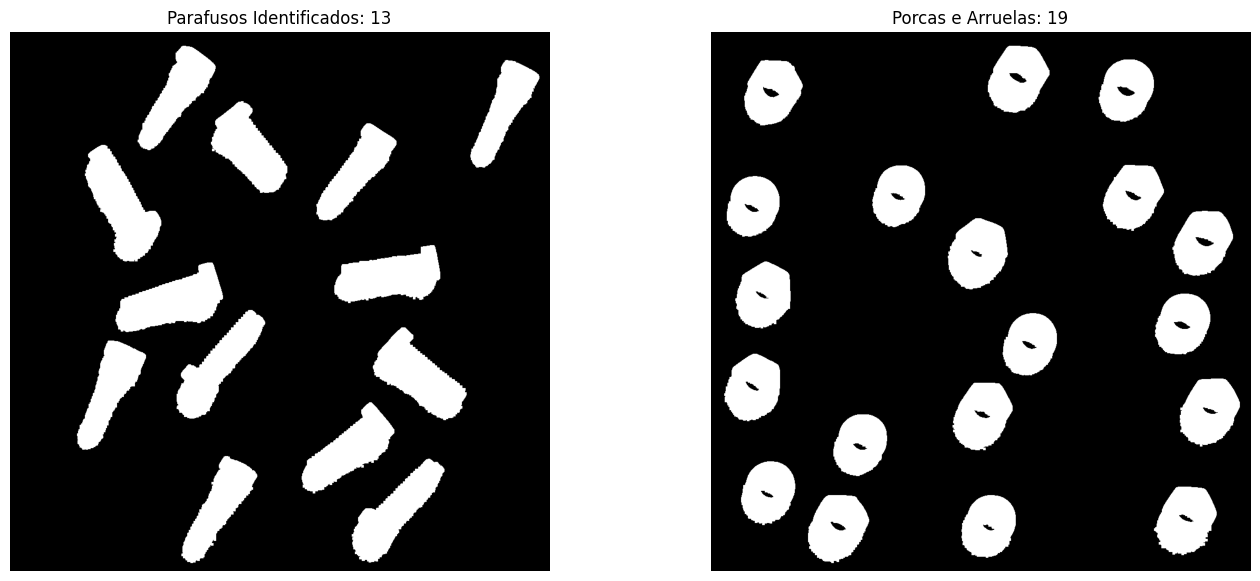

  ESTATÍSTICAS DO CONTROLE  
Quantidade de Parafusos       : 13
Quantidade de Porcas/Arruelas : 19
Total de Objetos              : 32


In [38]:
def count_connected_components(img):
    h, w = img.shape
    parent, rank = makeset(h * w + 1)

    for r in range(h):
        for c in range(w):
            if img[r, c] == 255:
                curr_id = r * w + c + 1
                for dr, dc in [(-1,-1), (-1,0), (-1,1), (0,-1)]:
                    nr, nc = r + dr, c + dc
                    if 0 <= nr < h and 0 <= nc < w and img[nr, nc] == 255:
                        union(curr_id, nr * w + nc + 1, parent, rank)

    label_img = np.zeros((h, w), dtype=int)
    roots = {}
    for r in range(h):
        for c in range(w):
            if img[r, c] == 255:
                root = find(r * w + c + 1, parent)
                if root not in roots:
                    roots[root] = len(roots) + 1
                label_img[r, c] = roots[root]
    return len(roots), label_img

def marca_conta_parafusos(img_binaria, img_complemento):
    num_total, label_img = count_connected_components(img_binaria)
    num_buracos, label_buracos = count_connected_components(img_complemento)

    tem_buraco = np.zeros(num_total + 1, dtype=bool)

    for b in range(1, num_buracos + 1):
        mask_buraco = (label_buracos == b)
        coords = np.argwhere(mask_buraco)

        if len(coords) > 0:
            area_buraco = len(coords)

            # pixel do buraco para checar a vizinhança na imagem original
            r, c = coords[0]
            for dr, dc in [(0,1), (0,-1), (1,0), (-1,0)]:
                nr, nc = r + dr, c + dc
                if 0 <= nr < img_binaria.shape[0] and 0 <= nc < img_binaria.shape[1]:
                    id_obj = label_img[nr, nc]
                    if id_obj > 0:
                        # se a área do buraco não for o fundo externo (muito grande),
                        # classificamos o objeto pai como tendo buraco
                        if area_buraco < 10000:
                            tem_buraco[id_obj] = True

    parafusos_img = np.zeros_like(img_binaria)
    contagem_parafusos = 0

    for i in range(1, num_total + 1):
        # parafusos = Objetos que NÃO têm buraco interno
        if not tem_buraco[i]:
            mask = (label_img == i)
            if np.sum(mask) > 100:
                parafusos_img[mask] = 255
                contagem_parafusos += 1

    return parafusos_img, contagem_parafusos


complement_filtered_img = complemento(filtered_img)

parafusos_img, num_parafusos = marca_conta_parafusos(filtered_img, complement_filtered_img)

subtracted_img = filtered_img.astype(np.int16) - parafusos_img.astype(np.int16)
subtracted_img = np.where(subtracted_img > 0, 255, 0).astype(np.uint8)

num_porcas_arruelas, _ = count_connected_components(subtracted_img)

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

ax[0].imshow(parafusos_img, cmap="gray")
ax[0].set_title(f"Parafusos Identificados: {num_parafusos}")
ax[0].axis("off")

ax[1].imshow(subtracted_img, cmap="gray")
ax[1].set_title(f"Porcas e Arruelas: {num_porcas_arruelas}")
ax[1].axis("off")

plt.subplots_adjust(wspace=0.3)
plt.show()

print("="*30)
print("  ESTATÍSTICAS DO CONTROLE  ")
print("="*30)
print(f"Quantidade de Parafusos       : {num_parafusos}")
print(f"Quantidade de Porcas/Arruelas : {num_porcas_arruelas}")
print(f"Total de Objetos              : {num_parafusos + num_porcas_arruelas}")
print("="*30)